In [3]:
import pandas as pd

car_v4 = pd.read_csv("car details v4.csv")
vehicle_df_first = pd.read_csv("vehicle_price_prediction.csv")
vehicle2_df = pd.read_csv("car_price_prediction_.csv")
ford_df = pd.read_csv('ford.csv')

step = len(vehicle_df_first) // 10000
vehicle_df = vehicle_df_first.iloc[::step].head(10000)


In [4]:
vehicle2_df.head()

,Car ID,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price,Model
0,1,Tesla,2016,2.3,Petrol,Manual,114832,New,26613.92,Model X
1,2,BMW,2018,4.4,Electric,Manual,143190,Used,14679.61,5 Series
2,3,Audi,2013,4.5,Electric,Manual,181601,New,44402.61,A4
3,4,Tesla,2011,4.1,Diesel,Automatic,68682,New,86374.33,Model Y
4,5,Ford,2009,2.6,Diesel,Manual,223009,Like New,73577.10,Mustang


In [5]:
car_v4_renamed = car_v4.rename(columns={
    'Make': 'make',
    'Model': 'model',
    'Year': 'year',
    'Kilometer': 'mileage',
    'Fuel Type': 'fuel_type',
    'Transmission': 'transmission',
    'Seller Type': 'seller_type',
    'Drivetrain': 'drivetrain',
    'Price': 'price'
}) #renaming the car_v4 columns to match the names in the vehicle price prediction columns

for i in vehicle_df.columns: #iterating through the vehicle price prediction columns
    if i not in car_v4_renamed.columns: #if the column is not in the car_v4 columns
        car_v4_renamed[i] = None #create a new column with the same name and fill with NaN

car_v4_renamed = car_v4_renamed[vehicle_df.columns] #reorder the columns in car_v4 to match the order of the vehicle price prediction columns


merged_df = pd.concat([vehicle_df, car_v4_renamed], ignore_index=True) #Merging the two datasets into one

#For the for loop and the pd.concat, I used ChatGPT to understand how I can use the pd.concat and how I can iterate through each column.
# The loop has some AI code, but the pd.concat is something I wrote from what AI gave me as an insight.


merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12059 entries, 0 to 12058
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   make              12059 non-null  object 
 1   model             12059 non-null  object 
 2   year              12059 non-null  int64  
 3   mileage           12059 non-null  int64  
 4   engine_hp         10000 non-null  object 
 5   transmission      12059 non-null  object 
 6   fuel_type         12059 non-null  object 
 7   drivetrain        11923 non-null  object 
 8   body_type         10000 non-null  object 
 9   exterior_color    10000 non-null  object 
 10  interior_color    10000 non-null  object 
 11  owner_count       10000 non-null  object 
 12  accident_history  2513 non-null   object 
 13  seller_type       12059 non-null  object 
 14  condition         10000 non-null  object 
 15  trim              10000 non-null  object 
 16  vehicle_age       10000 non-null  object

C:\Users\akgun\AppData\Local\Temp\ipykernel_27032\1026991357.py:20: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  merged_df = pd.concat([vehicle_df, car_v4_renamed], ignore_index=True) #Merging the two datasets into one


In [6]:
vehicle2_df_renamed = vehicle2_df.rename(columns={
    'Brand': 'make',
    'Model': 'model',
    'Year': 'year',
    'Mileage': 'mileage',       # or convert properly if needed
    'Fuel Type': 'fuel_type',
    'Transmission': 'transmission',
    'Price': 'price'
})

for col in vehicle_df.columns:
    if col not in vehicle2_df_renamed.columns:
        vehicle2_df_renamed[col] = None
vehicle2_df_renamed = vehicle2_df_renamed[vehicle_df.columns]

merged2_df =  pd.concat([vehicle_df, vehicle2_df_renamed], ignore_index=True) #Merging the two datasets into one

merged2_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12500 entries, 0 to 12499
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   make              12500 non-null  object 
 1   model             12500 non-null  object 
 2   year              12500 non-null  int64  
 3   mileage           12500 non-null  int64  
 4   engine_hp         10000 non-null  object 
 5   transmission      12500 non-null  object 
 6   fuel_type         12500 non-null  object 
 7   drivetrain        10000 non-null  object 
 8   body_type         10000 non-null  object 
 9   exterior_color    10000 non-null  object 
 10  interior_color    10000 non-null  object 
 11  owner_count       10000 non-null  object 
 12  accident_history  2513 non-null   object 
 13  seller_type       10000 non-null  object 
 14  condition         10000 non-null  object 
 15  trim              10000 non-null  object 
 16  vehicle_age       10000 non-null  object

C:\Users\akgun\AppData\Local\Temp\ipykernel_27032\3123649511.py:16: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  merged2_df =  pd.concat([vehicle_df, vehicle2_df_renamed], ignore_index=True) #Merging the two datasets into one


In [7]:
ford_df["make"] = "Ford"
ford_df = ford_df[ford_df['transmission'] != 'Semi-Auto']

ford_df_renamed = ford_df.rename(columns={
    'fuelType': 'fuel_type',
})

for col in merged2_df.columns:
    if col not in ford_df_renamed.columns:
        ford_df_renamed[col] = None
ford_df_renamed = ford_df_renamed[merged2_df.columns]

merged_final_df =  pd.concat([merged2_df, ford_df_renamed], ignore_index=True) #Merging the two datasets into one

merged_final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29379 entries, 0 to 29378
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   make              29379 non-null  object 
 1   model             29379 non-null  object 
 2   year              29379 non-null  int64  
 3   mileage           29379 non-null  int64  
 4   engine_hp         10000 non-null  object 
 5   transmission      29379 non-null  object 
 6   fuel_type         29379 non-null  object 
 7   drivetrain        10000 non-null  object 
 8   body_type         10000 non-null  object 
 9   exterior_color    10000 non-null  object 
 10  interior_color    10000 non-null  object 
 11  owner_count       10000 non-null  object 
 12  accident_history  2513 non-null   object 
 13  seller_type       10000 non-null  object 
 14  condition         10000 non-null  object 
 15  trim              10000 non-null  object 
 16  vehicle_age       10000 non-null  object

C:\Users\akgun\AppData\Local\Temp\ipykernel_27032\1129250472.py:13: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  merged_final_df =  pd.concat([merged2_df, ford_df_renamed], ignore_index=True) #Merging the two datasets into one


In [8]:
df_new = merged_final_df.drop(columns = ['exterior_color', 'interior_color', 'accident_history' , 'seller_type', 'trim', 'mileage_per_year', 'condition'])
df_new.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29379 entries, 0 to 29378
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   make              29379 non-null  object 
 1   model             29379 non-null  object 
 2   year              29379 non-null  int64  
 3   mileage           29379 non-null  int64  
 4   engine_hp         10000 non-null  object 
 5   transmission      29379 non-null  object 
 6   fuel_type         29379 non-null  object 
 7   drivetrain        10000 non-null  object 
 8   body_type         10000 non-null  object 
 9   owner_count       10000 non-null  object 
 10  vehicle_age       10000 non-null  object 
 11  brand_popularity  10000 non-null  float64
 12  price             29379 non-null  float64
dtypes: float64(2), int64(2), object(9)
memory usage: 2.9+ MB


In [9]:
df_new['engine_hp'] = (df_new['engine_hp'].astype(float))
df_new['owner_count'] = (df_new['owner_count'].astype(float))
df_new['vehicle_age'] = (df_new['vehicle_age'].astype(float))

In [10]:
df_new.head()

,make,model,year,mileage,engine_hp,transmission,fuel_type,drivetrain,body_type,owner_count,vehicle_age,brand_popularity,price
0,Volkswagen,Jetta,2016,183903,173.0,Manual,Electric,RWD,Sedan,5.0,9.0,0.040054,7208.52
1,Hyundai,Sonata,2016,151356,150.0,Manual,Gasoline,RWD,Sedan,3.0,9.0,0.039318,6573.14
2,Hyundai,Tucson,2013,172846,90.0,Automatic,Gasoline,FWD,Sedan,5.0,12.0,0.039318,1500.00
3,Chrysler,Pacifica,2016,114477,184.0,Manual,Electric,AWD,Sedan,5.0,9.0,0.040059,12555.49
4,Ford,Focus,2022,38978,208.0,Automatic,Gasoline,AWD,Pickup Truck,1.0,3.0,0.039842,22776.89


In [11]:
df_new.dtypes

make                 object
model                object
year                  int64
mileage               int64
engine_hp           float64
transmission         object
fuel_type            object
drivetrain           object
body_type            object
owner_count         float64
vehicle_age         float64
brand_popularity    float64
price               float64
dtype: object

In [12]:
import numpy as np
df_new['Transmission Class'] = np.where(df_new['transmission'] == 'Automatic',1,0)
df_new.head()

,make,model,year,mileage,engine_hp,transmission,fuel_type,drivetrain,body_type,owner_count,vehicle_age,brand_popularity,price,Transmission Class
0,Volkswagen,Jetta,2016,183903,173.0,Manual,Electric,RWD,Sedan,5.0,9.0,0.040054,7208.52,0
1,Hyundai,Sonata,2016,151356,150.0,Manual,Gasoline,RWD,Sedan,3.0,9.0,0.039318,6573.14,0
2,Hyundai,Tucson,2013,172846,90.0,Automatic,Gasoline,FWD,Sedan,5.0,12.0,0.039318,1500.00,1
3,Chrysler,Pacifica,2016,114477,184.0,Manual,Electric,AWD,Sedan,5.0,9.0,0.040059,12555.49,0
4,Ford,Focus,2022,38978,208.0,Automatic,Gasoline,AWD,Pickup Truck,1.0,3.0,0.039842,22776.89,1


In [97]:
df_new.to_csv("df_final_na.csv")

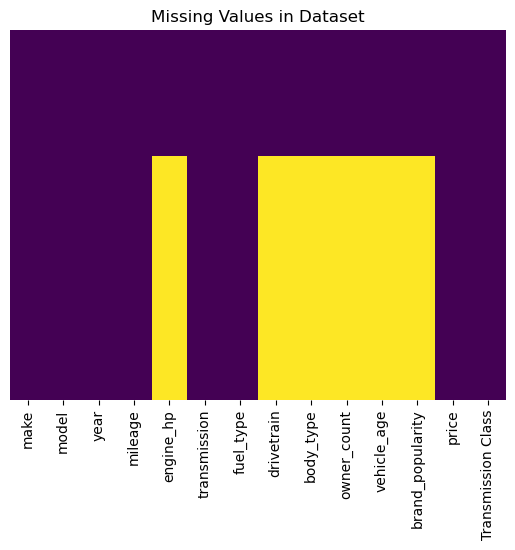

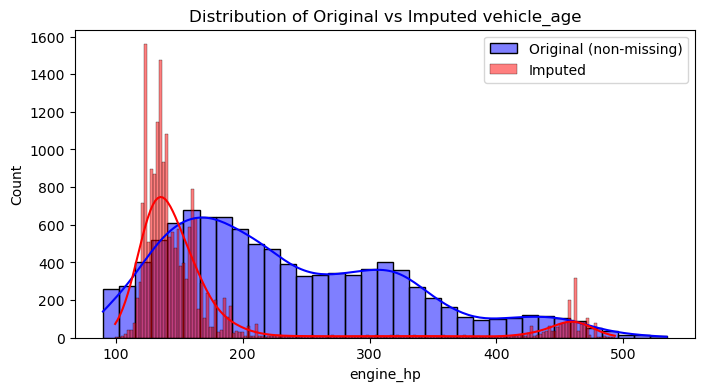


Original data statistics:
count    10000.000000
mean       235.312900
std         93.384034
min         90.000000
25%        162.000000
50%        214.000000
75%        300.000000
max        534.000000
Name: engine_hp, dtype: float64

Imputed data statistics:
count    29379.000000
mean       195.794881
std         97.627316
min         90.000000
25%        133.400000
50%        154.000000
75%        214.000000
max        534.000000
Name: engine_hp, dtype: float64


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

sns.heatmap(df_new.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Missing Values in Dataset')

plt.show()

# I used the week 6 ICA KNN example for my imputation method. The function and the code are from the ICA I have adjusted them to make them fit my data.

numeric_columns = ['price', 'mileage','engine_hp', 'owner_count', 'vehicle_age', 'brand_popularity'] #defining a list of columns for imputation
df_numeric = df_new[numeric_columns] #pulling only those specific columns from the dataset

df_with_missing = df_numeric[df_numeric.isnull().any(axis=1)] #rows with missing values
df_without_missing = df_numeric.dropna() #rows with no missing value

scaler = StandardScaler() #setting up the scaler
df_scaled = pd.DataFrame(scaler.fit_transform(df_without_missing), columns=df_without_missing.columns) #fits the scaled dataset to non-missing data and then transforms it from using what it learned 

imputer = KNNImputer(n_neighbors=5) #setting up the KNN imputer using the 5 nearest neighbors
imputer.fit(df_scaled) #Fitting the imputer to the scaled data

def impute_and_inverse_transform(data):
    
    scaled_data = pd.DataFrame(scaler.transform(data), columns=data.columns, index=data.index) #scale the data and transform using the initial scaler
    imputed_scaled = imputer.transform(scaled_data) #imputting the missing values to the scaled data using the initial imputer
    return pd.DataFrame(scaler.inverse_transform(imputed_scaled), columns=data.columns, index=data.index) #returns the inverted imputed data to get back the original data. (converts the z-score)

df_imputed = impute_and_inverse_transform(df_numeric) #using the impute and inverse function for the numeric columns to get rid of the missing values in columns if they have any

# compare original and imputed data
plt.figure(figsize=(8, 4))
sns.histplot(df_numeric['engine_hp'].dropna(), kde=True, color='blue', alpha=0.5, label='Original (non-missing)') #histogram plot for the original data
sns.histplot(df_imputed.loc[df_numeric['engine_hp'].isnull(), 'engine_hp'], kde=True, color='red', alpha=0.5, label='Imputed') #histogram plot for the imputed data
plt.title('Distribution of Original vs Imputed vehicle_age') #title for the plot
plt.legend() #showing the legend
plt.show()

# printing comparison
print("\nOriginal data statistics:")
print(df_numeric['engine_hp'].describe())
print("\nImputed data statistics:")
print(df_imputed['engine_hp'].describe())



In [58]:
mask = df_new[df_new['engine_hp'].isnull()]
#mask.head()
mask[mask['make'] == 'Tesla'].head()

,make,model,year,mileage,engine_hp,transmission,fuel_type,drivetrain,body_type,owner_count,vehicle_age,brand_popularity,price,Transmission Class
10000,Tesla,Model X,2016,114832,NaN,Manual,Petrol,None,None,NaN,NaN,NaN,26613.92,0
10003,Tesla,Model Y,2011,68682,NaN,Automatic,Diesel,None,None,NaN,NaN,NaN,86374.33,1
10007,Tesla,Model Y,2017,83030,NaN,Automatic,Hybrid,None,None,NaN,NaN,NaN,17381.19,1
10010,Tesla,Model 3,2001,298875,NaN,Automatic,Diesel,None,None,NaN,NaN,NaN,58872.60,1
10035,Tesla,Model 3,2004,171840,NaN,Manual,Petrol,None,None,NaN,NaN,NaN,29822.30,0


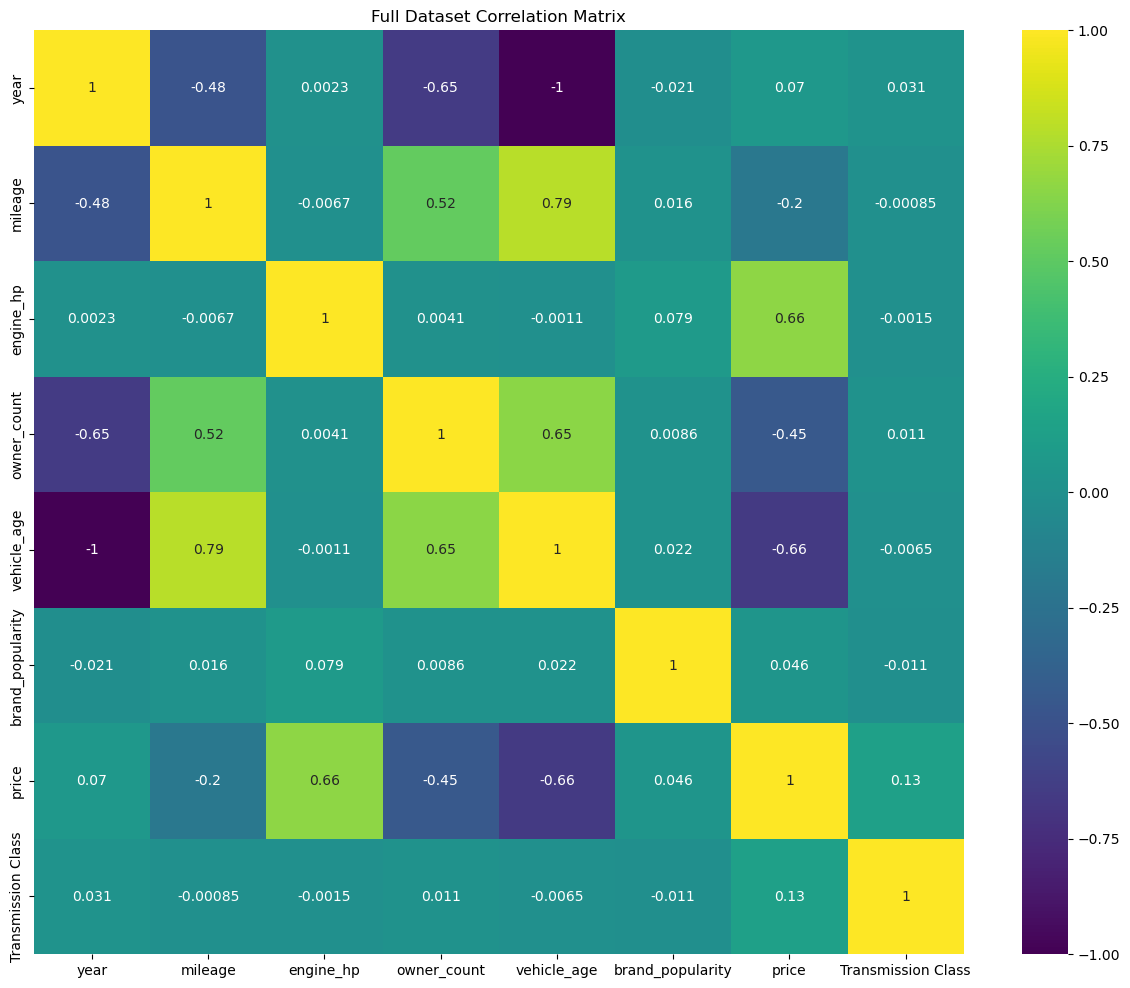

In [78]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#df_new[df_imputed.columns] = df_imputed
plt.figure(figsize=(15,12))
sns.heatmap(df_new.corr(numeric_only=True), annot=True, cmap = "viridis", vmin=-1, vmax=1)
plt.title("Full Dataset Correlation Matrix")
plt.show()


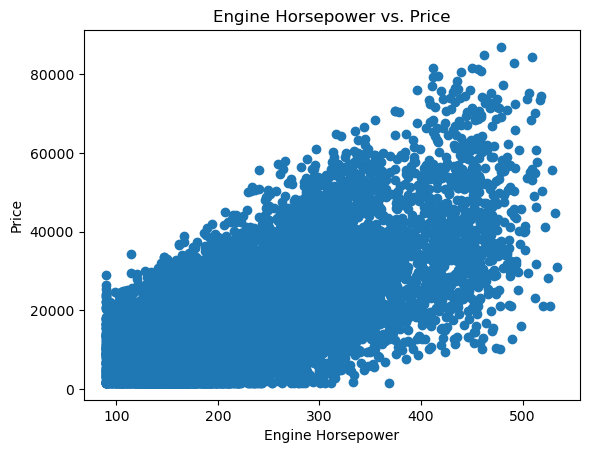

In [15]:
plt.scatter(df_new['engine_hp'], df_new['price'])
plt.xlabel("Engine Horsepower")
plt.ylabel("Price")
plt.title("Engine Horsepower vs. Price")


plt.show()

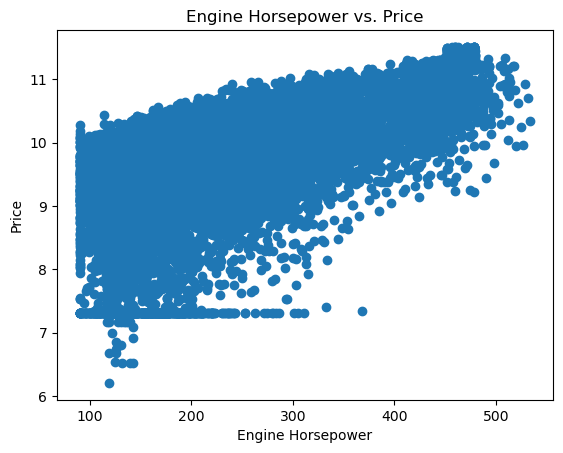

In [14]:
df_new2 = df_new.copy()
df_new2[df_imputed.columns] = df_imputed

plt.scatter(df_new2['engine_hp'], np.log(df_new2['price']))
plt.xlabel("Engine Horsepower")
plt.ylabel("Price")
plt.title("Engine Horsepower vs. Price")


plt.show()

In [96]:
df_new2.to_csv("df_final.csv")

In [135]:
df_new2['brand_popularity'].min()

0.039318

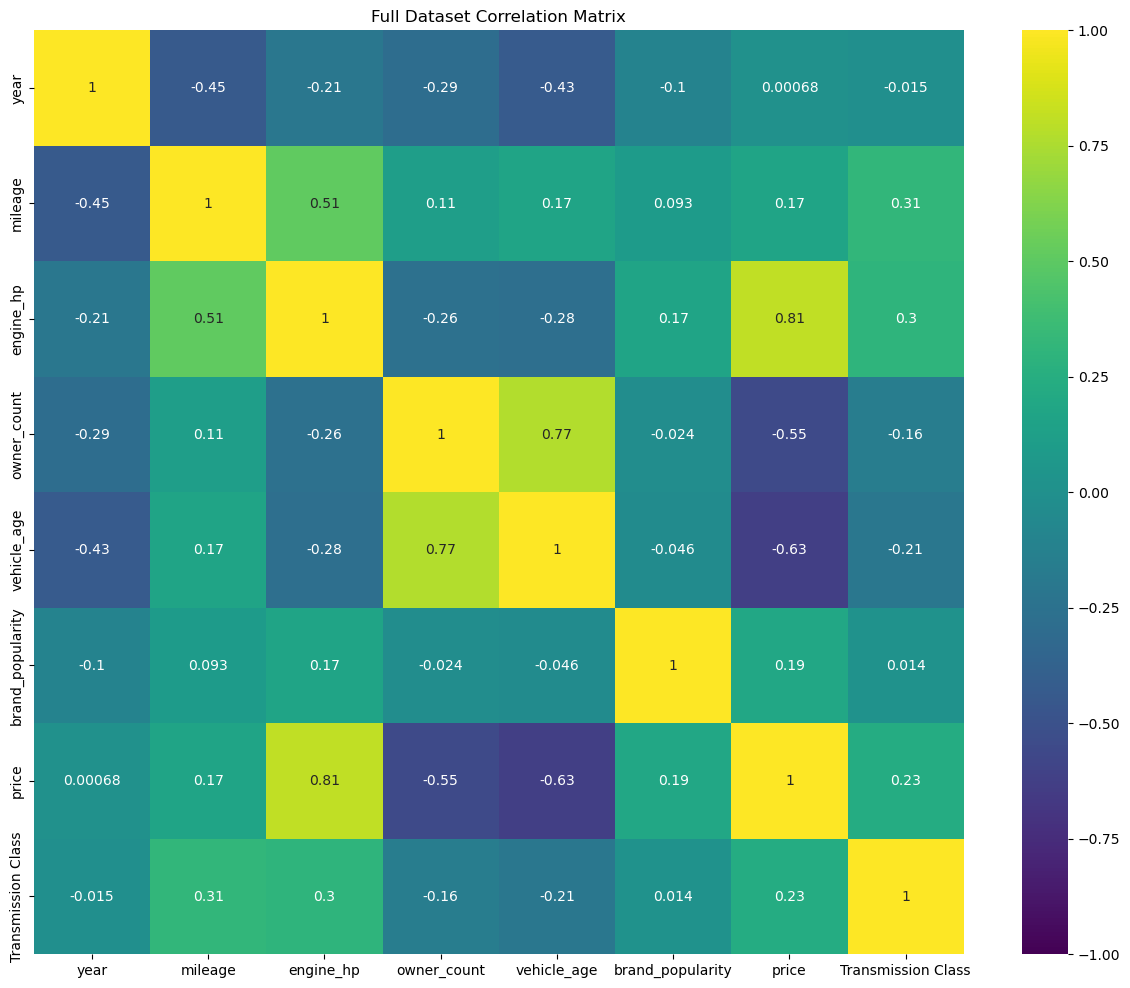

In [82]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#df_new[df_imputed.columns] = df_imputed
plt.figure(figsize=(15,12))
sns.heatmap(df_new2.corr(numeric_only=True), annot=True, cmap = "viridis", vmin=-1, vmax=1)
plt.title("Full Dataset Correlation Matrix")
plt.show()


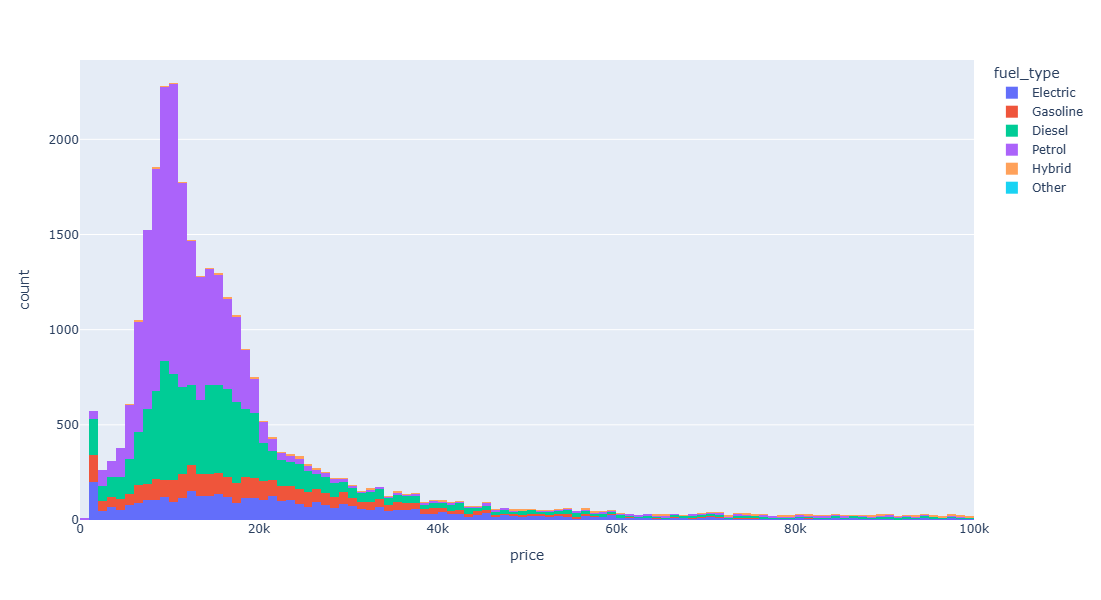

In [130]:
import plotly.express as px

fig = px.histogram(df_new2, x="price",color= "fuel_type",
                   width=1000,  
                   height=600)
fig.update_layout(
    xaxis=dict(range=[0.0, 100000.0]))

fig.show()

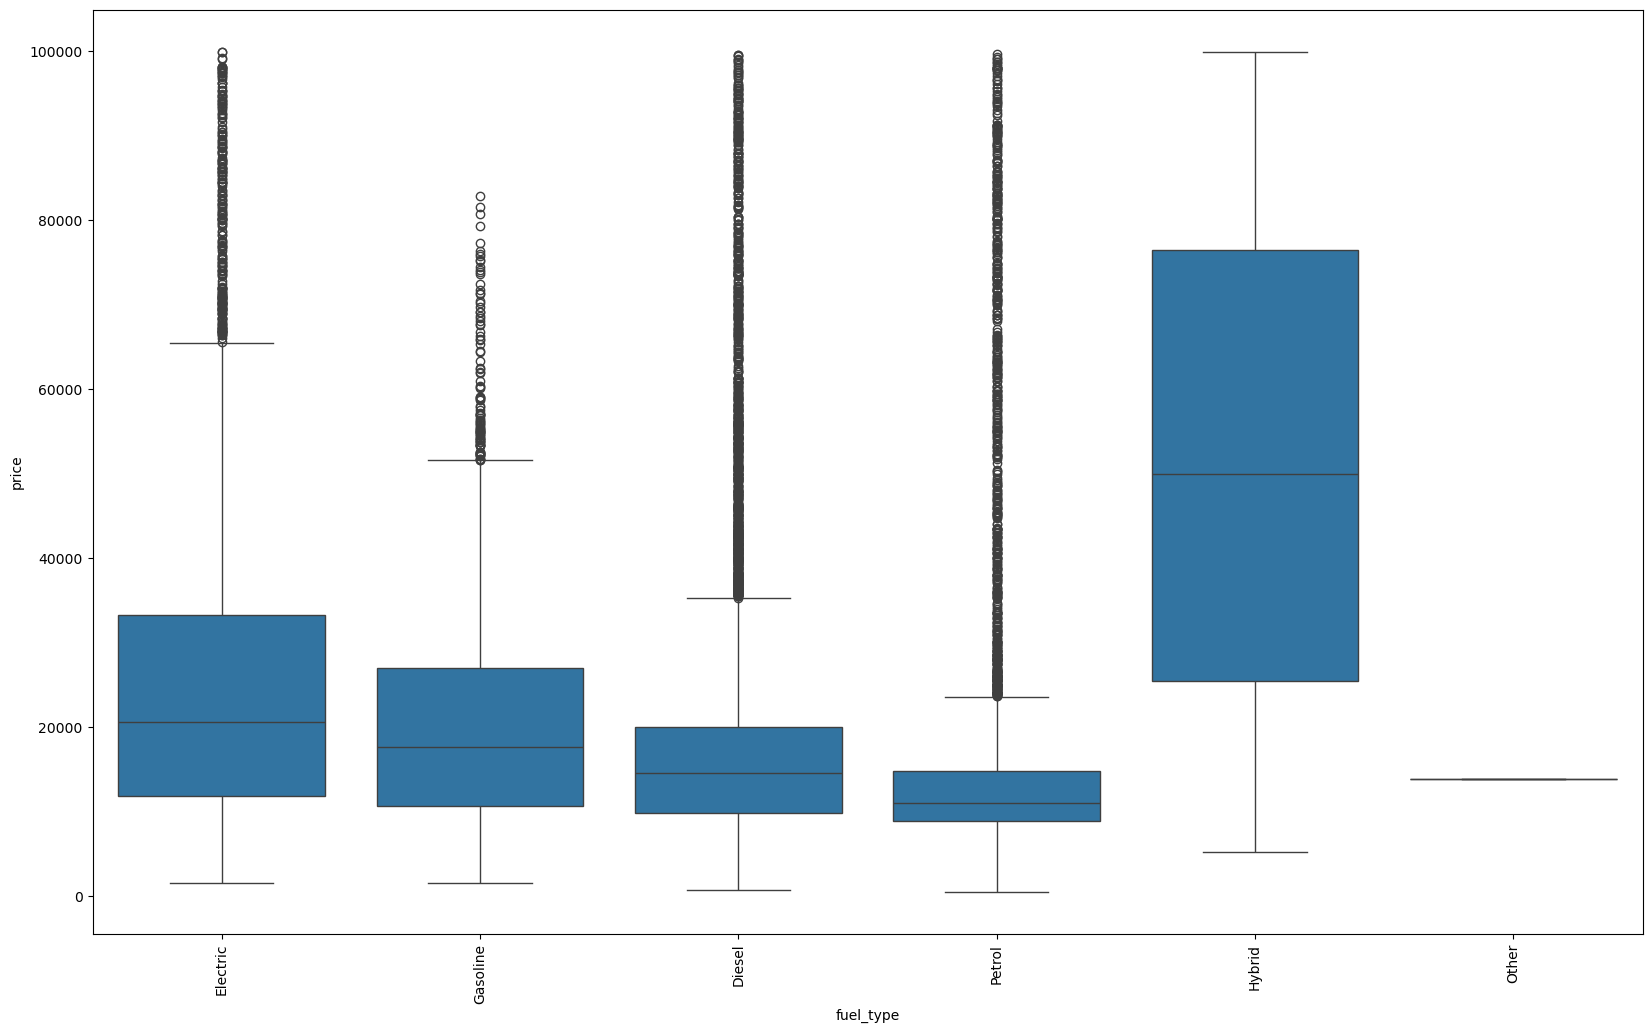

In [21]:
plt.figure(figsize=(20,12))
sns.boxplot(data=df_new2, x="fuel_type", y="price")
plt.xticks(rotation=90)
plt.show()

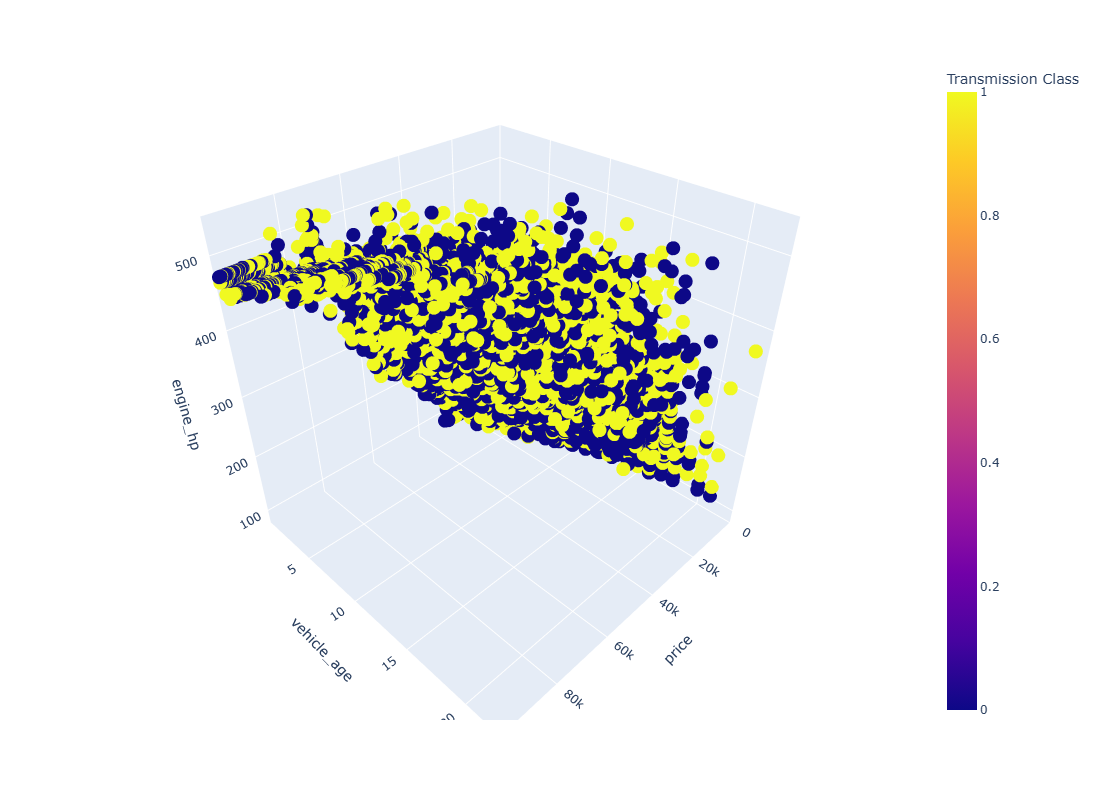

In [95]:
fig = px.scatter_3d(df_new2, x='price', y='vehicle_age', z='engine_hp',
              color='Transmission Class')
fig.update_layout(
    width=1000,   # increase this for wider figure
    height=800,
    scene=dict(
        xaxis=dict(range=[0, 100000])))
fig.show()

In [22]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso, Ridge
from sklearn.metrics import mean_squared_error, r2_score

categorical_cols = ['fuel_type'] 

df_encoded = pd.get_dummies(df_new2,columns=['fuel_type'],drop_first=True)      
X = df_encoded.drop(columns=['price','drivetrain','body_type', 'transmission','model','make'])  
y = df_encoded['price']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X) # scale X

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


lasso = Lasso(alpha=0.1)  
lasso.fit(X_train, y_train)

lasso_pred = lasso.predict(X_test)
lasso_mse = mean_squared_error(y_test, lasso_pred)
lasso_rmse = np.sqrt(lasso_mse)
lasso_r2 = r2_score(y_test, lasso_pred)


print("Lasso Coefficients:", lasso.coef_)
print("Lasso MSE:", lasso_mse)
print('lasso rmse:', lasso_rmse)
print("Lasso R²:", lasso_r2)


ridge = Ridge(alpha=1)  
ridge.fit(X_train, y_train)

ridge_pred = ridge.predict(X_test)
ridge_mse = mean_squared_error(y_test, ridge_pred)
ridge_rmse = np.sqrt(ridge_mse)
ridge_r2 = r2_score(y_test, ridge_pred)

print("Ridge Coefficients:", ridge.coef_)
print("Ridge MSE:", ridge_mse)
print('ridge rmse:',ridge_rmse)
print("Ridge R²:", ridge_r2)


Lasso Coefficients: [-1.46250889e+03 -2.48042815e+03  1.21801185e+04 -1.09124565e+03
 -6.44450080e+03  6.50520215e+02 -1.60356590e+02 -5.12434360e+02
 -5.19488099e+02  7.14137020e+02 -1.09045204e+01  9.52362296e+02]
Lasso MSE: 35815046.756061375
lasso rmse: 5984.567382531621
Lasso R²: 0.8725291857098009
Ridge Coefficients: [-1.46248982e+03 -2.48010526e+03  1.21794305e+04 -1.09173108e+03
 -6.44416592e+03  6.50661547e+02 -1.60366640e+02 -5.12430892e+02
 -5.19531360e+02  7.14323987e+02 -1.09848907e+01  9.52354774e+02]
Ridge MSE: 35815339.993183255
ridge rmse: 5984.591881923383
Ridge R²: 0.8725281420374316


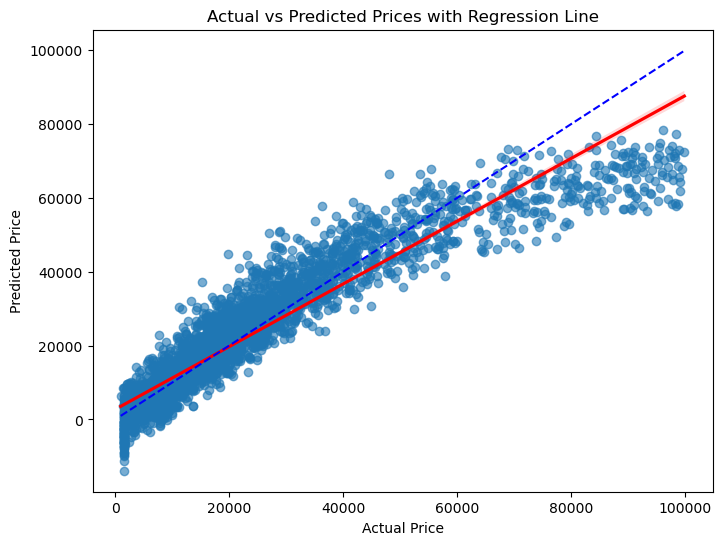

In [18]:
plt.figure(figsize=(8, 6)) # define the figure plot (kind of like the canvas in a painting)

sns.regplot(x=y_test, y=lasso_pred, scatter_kws={'alpha':0.6}, line_kws={'color':'red'}) # regression plot using seaborn
# sns.regplot finds the line that minimizes the rmse given the y_pred 

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'b--', label='Ideal line')
# plot the "ideal line". Let's say predictions are completely accurate, then it would be just the graph f(x) = x, since 
# actual = predicted.

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices with Regression Line")
plt.show()

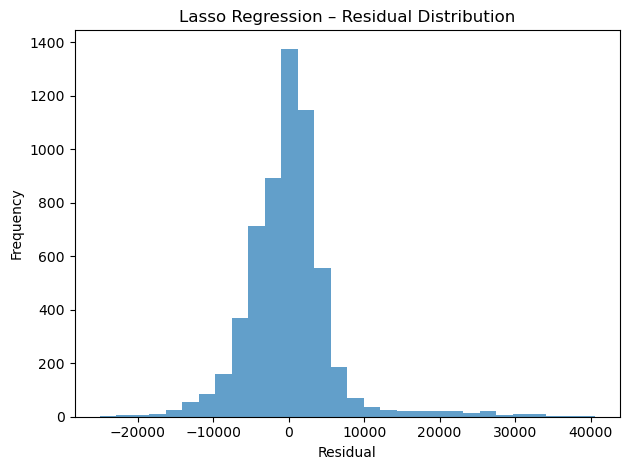

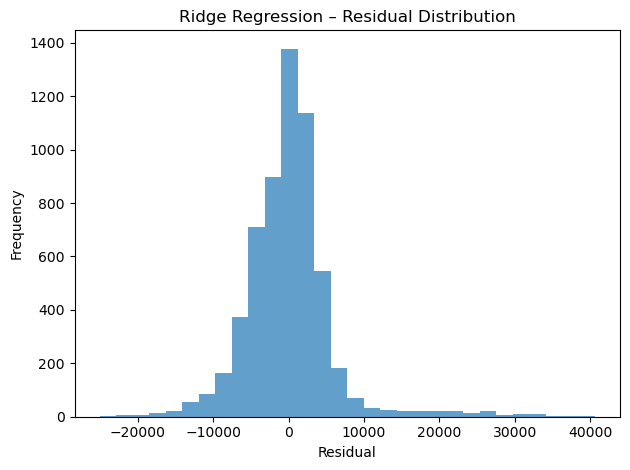

In [20]:
lasso_residuals = y_test - lasso_pred
ridge_residuals = y_test - ridge_pred

def plot_residuals(y_test, residuals, title):
    
    plt.hist(residuals, bins=30, alpha=0.7)
    plt.title(f"{title} – Residual Distribution")
    plt.xlabel("Residual")
    plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()
    
plot_residuals(y_test, lasso_residuals, "Lasso Regression")
plot_residuals(y_test, ridge_residuals, "Ridge Regression")